<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Quantum_Double_Slit_Experiment_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [8]:
!python -m pip install -q uv
!uv pip install --system -q cupy-cuda12x h5py

In [9]:
!pip install qutip ssqueezepy matplotlib numpy

In [10]:
# openEMS Colab installer.

import os
import shutil
import subprocess
import sys
import textwrap
from pathlib import Path


# =============================================================================
# CONTROL KNOBS
# =============================================================================

INSTALL_APT_PACKAGES = True
PYTHON_BRIDGE_REQUIRED = False
OCTAVE_BRIDGE_REQUIRED = False
RUN_APT_UPDATE = True

LOG_DIR = Path("/content/openems_install_logs")
BRIDGE_MODULE_PATH = Path("/content/openems_colab_bridge.py")
SMOKE_TEST_DIR = Path("/content/openems_smoke_tests")

APT_PACKAGES = (
    "openems",
    "python3-openems",
    "libopenems-dev",
    "octave-openems",
    "octave",
    "python3-numpy",
    "python3-h5py",
    "python3-matplotlib",
    "python3-scipy",
)

PYTHON_CANDIDATES = (
    "/usr/bin/python3",
    "/usr/bin/python3.10",
    "/usr/bin/python3.11",
)


# =============================================================================
# COMMAND HELPERS
# =============================================================================

def run_command(
    command: list[str],
    *,
    check: bool = True,
    env: dict[str, str] | None = None,
    cwd: Path | None = None,
    log_name: str | None = None,
) -> subprocess.CompletedProcess[str]:
    """Run a command, print its tail, and optionally save a log."""
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    print("$ " + " ".join(command))

    result = subprocess.run(
        command,
        check=False,
        cwd=str(cwd) if cwd is not None else None,
        env=env,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )

    output = result.stdout or ""
    if log_name is not None:
        path = LOG_DIR / log_name
        path.write_text(output, encoding="utf-8", errors="replace")
        print(f"log written to {path}")

    if output:
        print(output[-5000:])

    if check and result.returncode != 0:
        raise RuntimeError(
            f"Command failed with code {result.returncode}: "
            + " ".join(command)
        )

    return result


def command_exists(command_name: str) -> bool:
    """Return True when a command exists on PATH."""
    return shutil.which(command_name) is not None


def apt_candidate_exists(package_name: str) -> bool:
    """Return True when apt can install a package."""
    if not command_exists("apt-cache"):
        return False

    result = run_command(
        ["apt-cache", "policy", package_name],
        check=False,
        log_name=f"apt_policy_{package_name}.log",
    )
    text = result.stdout or ""
    return "Candidate:" in text and "Candidate: (none)" not in text


def apt_install_available(packages: tuple[str, ...]) -> None:
    """Install packages available from the current Colab apt repositories."""
    if RUN_APT_UPDATE:
        run_command(
            ["apt-get", "update", "-qq"],
            check=False,
            log_name="apt_update.log",
        )

    available = tuple(pkg for pkg in packages if apt_candidate_exists(pkg))
    skipped = tuple(pkg for pkg in packages if pkg not in available)

    if skipped:
        print("Skipped unavailable apt packages:")
        for package_name in skipped:
            print(f"  {package_name}")

    if not available:
        raise RuntimeError("No requested apt packages were available.")

    run_command(
        ["apt-get", "install", "-y", "-qq", *available],
        check=True,
        log_name="apt_install_openems.log",
    )


# =============================================================================
# ENVIRONMENTS AND DIAGNOSTICS
# =============================================================================

def clean_system_env() -> dict[str, str]:
    """Return a minimal environment for apt-provided Python bindings."""
    return {
        "HOME": os.environ.get("HOME", "/root"),
        "LANG": os.environ.get("LANG", "C.UTF-8"),
        "LC_ALL": os.environ.get("LC_ALL", "C.UTF-8"),
        "PATH": "/usr/bin:/bin:/usr/sbin:/sbin",
        "PYTHONNOUSERSITE": "1",
        "PYTHONPATH": "/usr/lib/python3/dist-packages",
    }


def openems_binaries_available() -> bool:
    """Return True when command-line openEMS executables are available."""
    ok = True
    for name in ("openEMS", "AppCSXCAD"):
        path = shutil.which(name)
        if path is None:
            print(f"Missing executable: {name}")
            ok = False
        else:
            print(f"Found executable: {name} -> {path}")
    return ok


def print_package_locations() -> None:
    """Print installed openEMS package locations for debugging."""
    for package_name in ("python3-openems", "openems", "octave-openems"):
        result = run_command(
            ["dpkg", "-L", package_name],
            check=False,
            env=clean_system_env(),
            log_name=f"dpkg_L_{package_name}.log",
        )
        if result.returncode == 0:
            interesting = [
                line
                for line in (result.stdout or "").splitlines()
                if (
                    "dist-packages" in line
                    or "/usr/share/openEMS" in line
                    or "/usr/share/CSXCAD" in line
                )
            ]
            print(f"Key files from {package_name}:")
            for line in interesting[:80]:
                print("  " + line)


# =============================================================================
# PYTHON AND OCTAVE PROBES
# =============================================================================

def python_probe_code() -> str:
    """Return the Python probe used to verify openEMS bindings."""
    return r'''
import importlib.util
import sys

print("python executable:", sys.executable)
print("python version:", sys.version.replace("\\n", " "))
print("sys.path:")
for item in sys.path:
    print("  " + str(item))

for module_name in ("CSXCAD", "openEMS"):
    spec = importlib.util.find_spec(module_name)
    print(f"spec {module_name}: {spec}")
    if spec is not None:
        print(f"origin {module_name}: {spec.origin}")
        print(f"locations {module_name}: {spec.submodule_search_locations}")

from CSXCAD import ContinuousStructure
from openEMS import openEMS

csx = ContinuousStructure()
fdtd = openEMS()

print("ContinuousStructure:", type(csx))
print("openEMS:", type(fdtd))
print("OPENEMS_PYTHON_BINDINGS_OK")
'''


def test_python_candidate(python_executable: str) -> bool:
    """Return True when one Python executable can import openEMS bindings."""
    if not Path(python_executable).exists():
        return False

    safe_name = Path(python_executable).name.replace(".", "_")
    result = run_command(
        [python_executable, "-c", python_probe_code()],
        check=False,
        env=clean_system_env(),
        log_name=f"probe_openems_{safe_name}.log",
    )
    return (
        result.returncode == 0
        and "OPENEMS_PYTHON_BINDINGS_OK" in (result.stdout or "")
    )


def select_openems_python() -> str | None:
    """Return a Python executable that can import openEMS, if one exists."""
    candidates = []
    candidates.extend(PYTHON_CANDIDATES)
    candidates.append(sys.executable)

    seen: set[str] = set()
    for candidate in candidates:
        path = shutil.which(candidate) if "/" not in candidate else candidate
        if path is None or path in seen:
            continue
        seen.add(path)
        print(f"Testing openEMS Python candidate: {path}")
        if test_python_candidate(path):
            print(f"Selected openEMS Python executable: {path}")
            return path

    return None


def octave_probe_code() -> str:
    """Return an Octave probe for the openEMS interface."""
    return """
addpath('/usr/share/openEMS/matlab');
addpath('/usr/share/CSXCAD/matlab');
disp('Octave path configured for openEMS');
which openEMS
which InitFDTD
which WriteOpenEMS
disp('OPENEMS_OCTAVE_INTERFACE_OK');
"""


def test_octave_interface() -> bool:
    """Return True when the Octave openEMS interface is available."""
    if not shutil.which("octave"):
        print("Octave executable is unavailable.")
        return False

    SMOKE_TEST_DIR.mkdir(parents=True, exist_ok=True)
    script_path = SMOKE_TEST_DIR / "openems_octave_probe.m"
    script_path.write_text(octave_probe_code(), encoding="utf-8")

    result = run_command(
        ["octave", "--quiet", str(script_path)],
        check=False,
        env=clean_system_env(),
        log_name="probe_openems_octave.log",
    )
    return (
        result.returncode == 0
        and "OPENEMS_OCTAVE_INTERFACE_OK" in (result.stdout or "")
    )


# =============================================================================
# BRIDGE MODULE WRITER
# =============================================================================

def write_bridge_module(
    python_executable: str | None,
    octave_available: bool,
) -> None:
    """Write a Colab bridge module without nested-string syntax hazards."""
    python_literal = repr(python_executable) if python_executable else "None"
    octave_literal = "True" if octave_available else "False"

    bridge_code = f'''
from __future__ import annotations

import os
import subprocess
import textwrap
from pathlib import Path
from typing import Mapping


OPENEMS_PYTHON = {python_literal}
OCTAVE_AVAILABLE = {octave_literal}
DEFAULT_WORK_DIR = Path("/content/openems_runs")


def _base_env(extra_env: Mapping[str, str] | None = None) -> dict[str, str]:
    env = {{
        "HOME": os.environ.get("HOME", "/root"),
        "LANG": os.environ.get("LANG", "C.UTF-8"),
        "LC_ALL": os.environ.get("LC_ALL", "C.UTF-8"),
        "PATH": "/usr/bin:/bin:/usr/sbin:/sbin",
        "PYTHONNOUSERSITE": "1",
        "PYTHONPATH": "/usr/lib/python3/dist-packages",
    }}
    if extra_env:
        env.update({{str(key): str(value) for key, value in extra_env.items()}})
    return env


def run_openems_binary(
    xml_path: str | Path,
    *,
    work_dir: str | Path | None = None,
    check: bool = True,
) -> subprocess.CompletedProcess[str]:
    path = Path(xml_path)
    cwd = Path(work_dir) if work_dir is not None else path.parent
    result = subprocess.run(
        ["/usr/bin/openEMS", str(path)],
        cwd=str(cwd),
        env=_base_env(),
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    print(result.stdout)
    if check and result.returncode != 0:
        raise subprocess.CalledProcessError(
            result.returncode,
            result.args,
            output=result.stdout,
        )
    return result


def run_openems_python_script(
    script_path: str | Path,
    *,
    work_dir: str | Path | None = None,
    extra_env: Mapping[str, str] | None = None,
    check: bool = True,
) -> subprocess.CompletedProcess[str]:
    if OPENEMS_PYTHON is None:
        raise RuntimeError(
            "No compatible openEMS Python binding was found. "
            "Use run_openems_octave_code() or run_openems_binary()."
        )

    path = Path(script_path)
    cwd = Path(work_dir) if work_dir is not None else path.parent
    cwd.mkdir(parents=True, exist_ok=True)

    result = subprocess.run(
        [OPENEMS_PYTHON, str(path)],
        cwd=str(cwd),
        env=_base_env(extra_env),
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    print(result.stdout)
    if check and result.returncode != 0:
        raise subprocess.CalledProcessError(
            result.returncode,
            result.args,
            output=result.stdout,
        )
    return result


def run_openems_python_code(
    code: str,
    *,
    work_dir: str | Path = DEFAULT_WORK_DIR,
    filename: str = "openems_case.py",
    extra_env: Mapping[str, str] | None = None,
    check: bool = True,
) -> subprocess.CompletedProcess[str]:
    cwd = Path(work_dir)
    cwd.mkdir(parents=True, exist_ok=True)
    script_path = cwd / filename
    script_path.write_text(
        textwrap.dedent(code).strip() + "\\n",
        encoding="utf-8",
    )
    return run_openems_python_script(
        script_path,
        work_dir=cwd,
        extra_env=extra_env,
        check=check,
    )


def run_openems_octave_code(
    code: str,
    *,
    work_dir: str | Path = DEFAULT_WORK_DIR,
    filename: str = "openems_case.m",
    check: bool = True,
) -> subprocess.CompletedProcess[str]:
    if not OCTAVE_AVAILABLE:
        raise RuntimeError("The Octave openEMS interface was unavailable.")

    cwd = Path(work_dir)
    cwd.mkdir(parents=True, exist_ok=True)
    script_path = cwd / filename
    prefix = """
addpath('/usr/share/openEMS/matlab');
addpath('/usr/share/CSXCAD/matlab');
"""
    script_path.write_text(
        textwrap.dedent(prefix + "\\n" + code).strip() + "\\n",
        encoding="utf-8",
    )

    result = subprocess.run(
        ["/usr/bin/octave", "--quiet", str(script_path)],
        cwd=str(cwd),
        env=_base_env(),
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        check=False,
    )
    print(result.stdout)
    if check and result.returncode != 0:
        raise subprocess.CalledProcessError(
            result.returncode,
            result.args,
            output=result.stdout,
        )
    return result
'''
    BRIDGE_MODULE_PATH.write_text(
        textwrap.dedent(bridge_code).strip() + "\n",
        encoding="utf-8",
    )
    print(f"Wrote bridge module: {BRIDGE_MODULE_PATH}")


# =============================================================================
# MAIN
# =============================================================================

def main() -> None:
    """Install openEMS and write a robust Colab bridge."""
    print("openEMS Colab installer")
    print(f"Notebook Python: {sys.executable}")
    print(f"Log directory:   {LOG_DIR}")

    if INSTALL_APT_PACKAGES:
        apt_install_available(APT_PACKAGES)

    binaries_ok = openems_binaries_available()
    if not binaries_ok:
        raise RuntimeError("openEMS command-line binaries were unavailable.")

    print_package_locations()

    openems_python = select_openems_python()
    octave_ok = test_octave_interface()

    if PYTHON_BRIDGE_REQUIRED and openems_python is None:
        raise RuntimeError(
            "A compatible Python binding was not found. "
            f"See logs in {LOG_DIR}."
        )

    if OCTAVE_BRIDGE_REQUIRED and not octave_ok:
        raise RuntimeError(
            "The Octave openEMS interface was not found. "
            f"See logs in {LOG_DIR}."
        )

    write_bridge_module(openems_python, octave_ok)

    print("\nInstallation summary")
    print(f"  openEMS binaries:      {binaries_ok}")
    print(f"  Python binding bridge: {openems_python}")
    print(f"  Octave bridge:         {octave_ok}")

    print("\nUse this in later Colab cells:")
    print(
        "import sys\n"
        "sys.path.insert(0, '/content')\n"
        "from openems_colab_bridge import (\n"
        "    run_openems_binary,\n"
        "    run_openems_octave_code,\n"
        "    run_openems_python_code,\n"
        ")\n"
    )

    if openems_python is not None:
        print(
            "run_openems_python_code(\"\"\"\n"
            "from CSXCAD import ContinuousStructure\n"
            "from openEMS import openEMS\n"
            "print('openEMS Python bridge works')\n"
            "\"\"\")\n"
        )
    elif octave_ok:
        print(
            "run_openems_octave_code(\"\"\"\n"
            "disp('openEMS Octave bridge works');\n"
            "which openEMS\n"
            "\"\"\")\n"
        )
    else:
        print(
            "# Python and Octave interfaces were unavailable, but the openEMS "
            "binary can still run XML files:\n"
            "# run_openems_binary('/content/path/to/simulation.xml')\n"
        )

main()

openEMS Colab installer
Notebook Python: /usr/bin/python3
Log directory:   /content/openems_install_logs
$ apt-get update -qq
log written to /content/openems_install_logs/apt_update.log
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)

$ apt-cache policy openems
log written to /content/openems_install_logs/apt_policy_openems.log
openems:
  Installed: 0.0.35+git20190103.6a75e98+dfsg.1-3.1build1
  Candidate: 0.0.35+git20190103.6a75e98+dfsg.1-3.1build1
  Version table:
 *** 0.0.35+git20190103.6a75e98+dfsg.1-3.1build1 500
        500 http://archive.ubuntu.com/ubuntu jammy/universe amd64 Packages
        100 /var/lib/dpkg/status

$ apt-cache policy python3-openems
log written to /content/openems_install_logs/apt_policy_python3-openems.log
python3-openems:
  Installed: 0.0.35+git20190103.6a75e98+dfsg.1-3.1build1
  Candidate: 0.0.35+git20190103.6a75e98+df

In [13]:
"""Preflight check for the openEMS Colab bridge and generated run directory."""

from pathlib import Path
import sys

# =============================================================================
# CONTROL KNOBS
# =============================================================================

CONTENT_ROOT = Path("/content")
BRIDGE_PATH = CONTENT_ROOT / "openems_colab_bridge.py"
OPENEMS_WORK_DIR = CONTENT_ROOT / "openems_double_slit"
OPENEMS_RUN_DIR = OPENEMS_WORK_DIR / "fdtd_run"

print("Checking Colab openEMS state.")
print(f"Bridge path: {BRIDGE_PATH}")
print(f"Bridge exists: {BRIDGE_PATH.exists()}")

if BRIDGE_PATH.exists() is False:
    raise FileNotFoundError(
        "openems_colab_bridge.py is missing. Rerun the openEMS installer cell."
    )

OPENEMS_WORK_DIR.mkdir(parents=True, exist_ok=True)
OPENEMS_RUN_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(CONTENT_ROOT))
from openems_colab_bridge import run_openems_python_code

run_openems_python_code(
    """
from CSXCAD import ContinuousStructure
from openEMS import openEMS

csx = ContinuousStructure()
fdtd = openEMS()
print("openEMS Python bridge works from /usr/bin/python3.10")
""",
    work_dir=str(OPENEMS_WORK_DIR),
    filename="openems_bridge_preflight.py",
    check=True,
)

print(f"Created or verified work directory: {OPENEMS_WORK_DIR}")
print(f"Created or verified run directory:  {OPENEMS_RUN_DIR}")

Checking Colab openEMS state.
Bridge path: /content/openems_colab_bridge.py
Bridge exists: True
openEMS Python bridge works from /usr/bin/python3.10

Created or verified work directory: /content/openems_double_slit
Created or verified run directory:  /content/openems_double_slit/fdtd_run


openEMS bridge verification passed.

BRUTE_FORCE_OPENEMS_HDF5_IMAGE_RESAMPLER_2026_07_06
Scalar fallback is disabled. The EM panel comes from openEMS HDF5 data.
Quantum propagation backend: CuPy GPU on Tesla T4
Trying existing openEMS HDF5 files first.
openEMS HDF5 brute-force reader
  Backend: CuPy GPU on Tesla T4
  Candidate peaks:
    Ez_fd.h5 component 2 FieldData/FD/f0_real: 3.135578e-27
    Ez_fd.h5 component 0 FieldData/FD/f0_real: 0.000000e+00
    Ez_fd.h5 component 1 FieldData/FD/f0_real: 0.000000e+00
  Selected file: /content/openems_double_slit/fdtd_run/Ez_fd.h5
  Selected component: 2
  Selected raw peak: 3.135578e-27
openEMS raw image shape: (192, 337)
openEMS resized map peak: 1.000000e+00
openEMS display map peak: 1.000000e+00
openEMS detector peak: 1.000000e+00


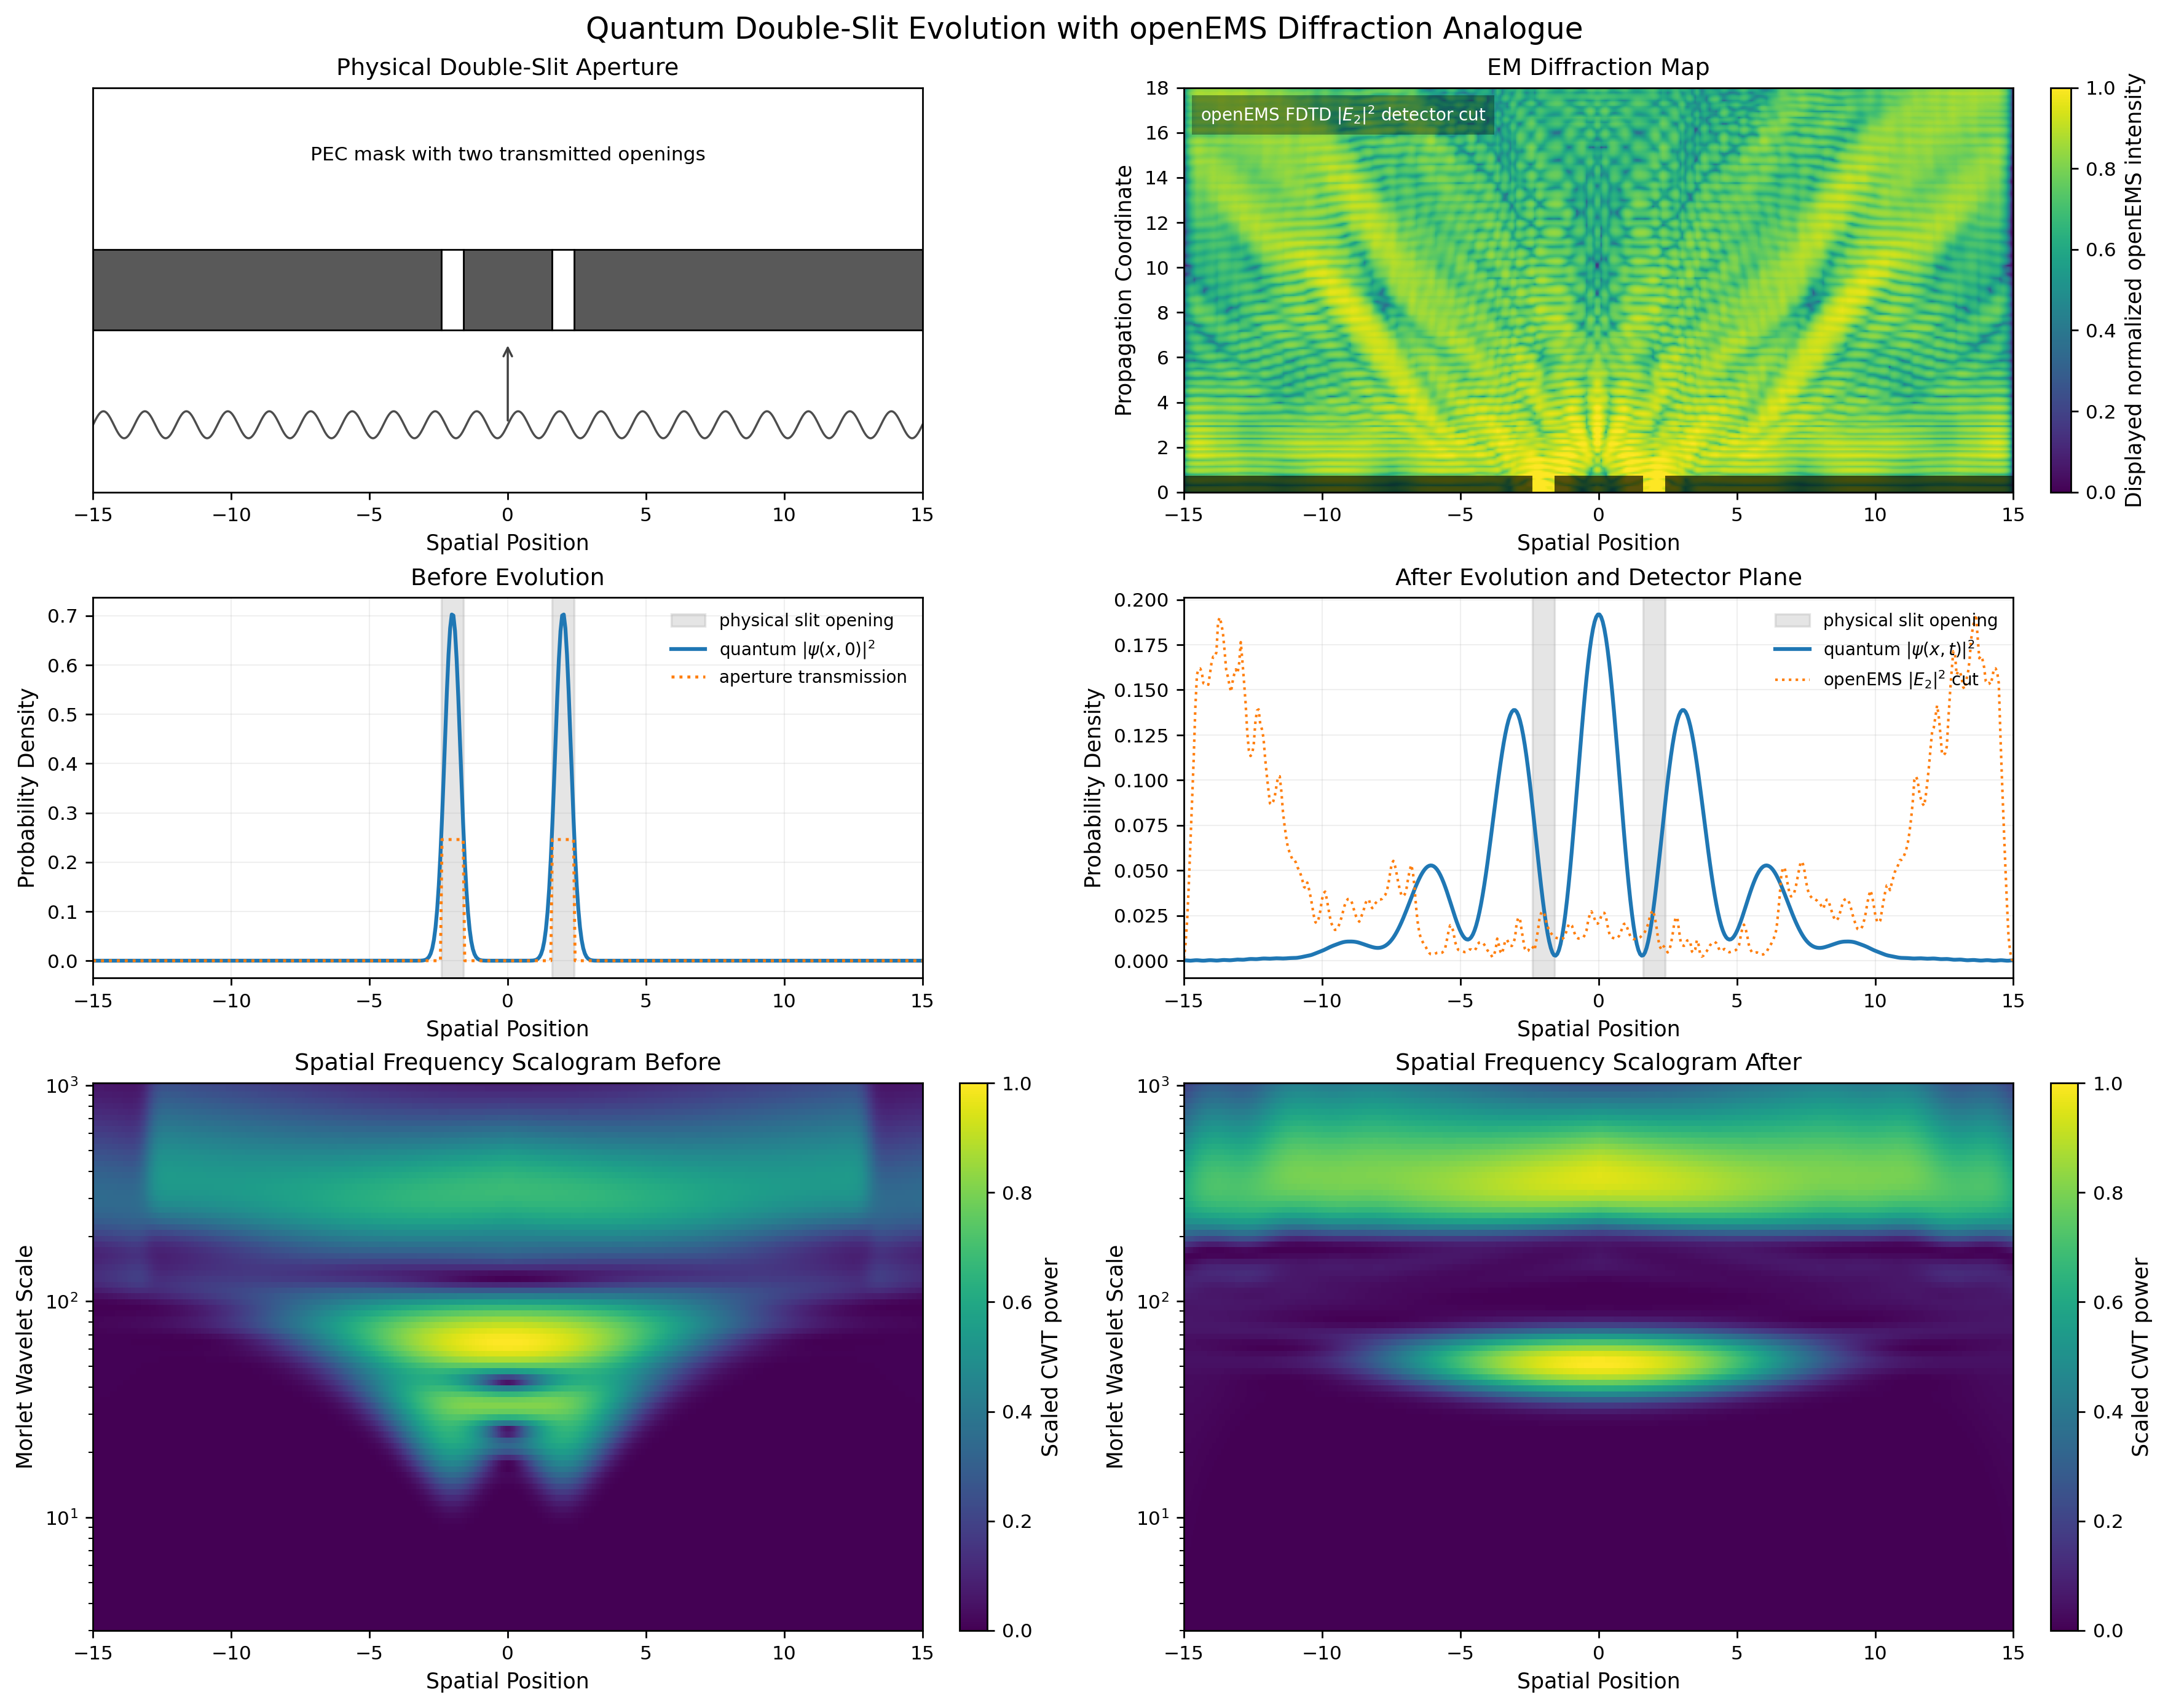

Selected openEMS HDF5: /content/openems_double_slit/fdtd_run/Ez_fd.h5
Selected openEMS component: 2


In [16]:
"""Standalone quantum double-slit with mandatory openEMS and CuPy postprocessing.
"""

from dataclasses import dataclass
from pathlib import Path
import importlib.util
import shutil
import subprocess
import sys
import textwrap
from typing import Any

# =========================================================================
# CONTROL KNOBS
# =========================================================================

@dataclass(frozen=True)
class ControlKnobs:
    """Main knobs for runtime setup, geometry, openEMS, GPU, and plotting."""

    install_missing_packages: bool = True
    use_cupy_when_available: bool = True

    bridge_path: str = "/content/openems_colab_bridge.py"
    openems_work_dir: str = "/content/openems_double_slit"
    openems_force_rerun: bool = False
    rerun_if_existing_hdf5_is_zero: bool = True

    grid_points: int = 512
    x_max: float = 15.0

    slit_separation: float = 4.0
    slit_width: float = 0.4
    physical_slit_width: float = 0.8

    evolution_time: float = 2.0
    particle_mass: float = 1.0
    hbar: float = 1.0

    openems_unit_m: float = 1e-6
    openems_wavelength: float = 0.75
    openems_points_per_wavelength: int = 5
    openems_source_y: float = -4.0
    openems_source_width: float = 0.35
    openems_source_x_inset_wavelengths: float = 1.0
    openems_mask_y: float = 0.0
    openems_detector_y: float = 18.0
    openems_y_margin: float = 2.0
    openems_mask_thickness: float = 0.50
    openems_z_half_span: float = 0.20
    openems_end_criteria: float = 0.0
    openems_nr_ts: int = 3600
    openems_fc_fraction: float = 0.25
    openems_z_boundary: str = "PEC"

    hdf5_component_mode: str = "strongest"
    z_reduction_mode: str = "mean"

    em_plot_y_points: int = 260
    em_detector_average_rows: int = 7
    em_display_percentile: float = 99.5
    em_dynamic_range_db: float = 42.0
    em_display_gamma: float = 0.70
    em_gaussian_sigma_y: float = 0.40
    em_gaussian_sigma_x: float = 0.20

    cwt_min_scale: float = 3.0
    cwt_max_scale: float = 1024.0
    cwt_num_scales: int = 96
    cwt_omega0: float = 6.0
    cwt_log_gain: float = 35.0

    figure_dpi: int = 250
    figure_size: tuple[float, float] = (14.0, 11.0)
    diagnostic_prints: bool = True


CONFIG = ControlKnobs()


# =============================================================================
# PACKAGE SETUP
# =============================================================================

def module_available(module_name: str) -> bool:
    """Return True when a module is importable."""

    return importlib.util.find_spec(module_name) is not None


def run_command(command: list[str], check: bool = True) -> str:
    """Run a shell command and return its combined output."""

    result = subprocess.run(
        command,
        check=False,
        encoding="utf-8",
        errors="replace",
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )

    if check and result.returncode != 0:
        raise RuntimeError(
            "Command failed with return code "
            f"{result.returncode}: {' '.join(command)}\n{result.stdout}"
        )

    return result.stdout


def install_with_uv(packages: list[str]) -> None:
    """Install packages with uv pip and use pip as fallback."""

    if not packages:
        return

    run_command([sys.executable, "-m", "pip", "install", "-q", "uv"])
    result = subprocess.run(
        [
            sys.executable,
            "-m",
            "uv",
            "pip",
            "install",
            "--system",
            "-q",
            *packages,
        ],
        check=False,
        encoding="utf-8",
        errors="replace",
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )

    if result.returncode != 0:
        print("uv pip failed, so pip fallback is being used.")
        print(result.stdout)
        run_command([sys.executable, "-m", "pip", "install", "-q", *packages])


def ensure_packages(config: ControlKnobs) -> None:
    """Install notebook-side packages if they are missing."""

    if not config.install_missing_packages:
        return

    package_map = {
        "numpy": "numpy",
        "matplotlib": "matplotlib",
        "scipy": "scipy",
        "h5py": "h5py",
    }
    missing = [
        package_name
        for module_name, package_name in package_map.items()
        if not module_available(module_name)
    ]

    if missing:
        install_with_uv(missing)


ensure_packages(CONFIG)


# =============================================================================
# IMPORTS
# =============================================================================

import h5py
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as ndi


# =============================================================================
# OPENEMS BRIDGE
# =============================================================================

def import_openems_bridge(config: ControlKnobs):
    """Import the existing openEMS bridge from /content."""

    bridge_path = Path(config.bridge_path)

    if not bridge_path.exists():
        raise FileNotFoundError(
            f"Missing bridge file: {bridge_path}. "
            "Run your openEMS installer or preflight cell first."
        )

    sys.path.insert(0, str(bridge_path.parent))
    from openems_colab_bridge import run_openems_python_code

    return run_openems_python_code


RUN_OPENEMS_PYTHON_CODE = import_openems_bridge(CONFIG)


def verify_bridge(config: ControlKnobs) -> None:
    """Verify that the bridge can import openEMS through Python 3.10."""

    work_dir = Path(config.openems_work_dir)
    work_dir.mkdir(parents=True, exist_ok=True)

    RUN_OPENEMS_PYTHON_CODE(
        """
from CSXCAD import ContinuousStructure
from openEMS import openEMS

csx = ContinuousStructure()
fdtd = openEMS()
print("openEMS bridge verification passed.")
""",
        work_dir=str(work_dir),
        filename="openems_bridge_verification.py",
        check=True,
    )


verify_bridge(CONFIG)


# =============================================================================
# DATA CONTAINERS
# =============================================================================

@dataclass(frozen=True)
class QuantumResult:
    """Container for the quantum calculation."""

    x_grid: np.ndarray
    dx: float
    prob_initial: np.ndarray
    prob_final: np.ndarray
    cwt_initial: np.ndarray
    cwt_final: np.ndarray
    cwt_scales: np.ndarray


@dataclass(frozen=True)
class EMResult:
    """Container for the openEMS field result."""

    x_grid: np.ndarray
    y_grid: np.ndarray
    display_intensity_map: np.ndarray
    normalized_intensity_map: np.ndarray
    detector_intensity: np.ndarray
    selected_component: int
    selected_hdf5: str


# =============================================================================
# GPU HELPERS
# =============================================================================

def get_array_backend(config: ControlKnobs) -> tuple[Any, str]:
    """Return CuPy when available, otherwise return NumPy."""

    if not config.use_cupy_when_available:
        return np, "NumPy CPU"

    try:
        import cupy as cp

        if cp.cuda.runtime.getDeviceCount() < 1:
            return np, "NumPy CPU"

        device = cp.cuda.Device()
        properties = cp.cuda.runtime.getDeviceProperties(device.id)
        device_name = properties.get("name", "CUDA GPU")

        if isinstance(device_name, bytes):
            device_name = device_name.decode("utf-8", errors="replace")

        return cp, f"CuPy GPU on {device_name}"

    except Exception as error:
        print("CuPy unavailable. NumPy CPU arrays will be used.")
        print(f"CuPy detail: {error}")
        return np, "NumPy CPU"


def to_numpy(values: Any, xp: Any) -> np.ndarray:
    """Move values from GPU memory to host memory when needed."""

    if getattr(xp, "__name__", "") == "cupy":
        return xp.asnumpy(values)

    return np.asarray(values)


# =============================================================================
# NUMERICAL HELPERS
# =============================================================================

def configure_matplotlib(config: ControlKnobs) -> None:
    """Set plotting defaults."""

    mpl.rcParams.update(
        {
            "figure.dpi": config.figure_dpi,
            "font.family": "sans-serif",
            "font.sans-serif": ["Tahoma", "DejaVu Sans", "Arial"],
            "font.weight": "normal",
            "axes.titlesize": 11,
            "axes.labelsize": 10,
            "xtick.labelsize": 9,
            "ytick.labelsize": 9,
            "legend.fontsize": 8,
        }
    )


def validate_config(config: ControlKnobs) -> None:
    """Validate primary geometry and solver controls."""

    if config.grid_points < 128:
        raise ValueError("grid_points must be at least 128.")

    if config.x_max <= 0.0:
        raise ValueError("x_max must be positive.")

    if config.physical_slit_width <= 0.0:
        raise ValueError("physical_slit_width must be positive.")

    if config.slit_separation <= config.physical_slit_width:
        raise ValueError("slit_separation must exceed physical_slit_width.")

    if config.openems_wavelength <= 0.0:
        raise ValueError("openems_wavelength must be positive.")

    if config.openems_points_per_wavelength < 3:
        raise ValueError("openems_points_per_wavelength must be at least 3.")


def normalize_to_unit(values: np.ndarray) -> np.ndarray:
    """Normalize an array into the unit interval."""

    array = np.asarray(values, dtype=np.float64)
    array = np.nan_to_num(array, nan=0.0, posinf=0.0, neginf=0.0)
    array = array - float(np.min(array))
    peak = float(np.max(array))

    if peak <= 0.0:
        return np.zeros_like(array)

    return array / peak


def normalize_positive_map(values: np.ndarray) -> np.ndarray:
    """Normalize a positive map without losing tiny nonzero fields."""

    array = np.asarray(values, dtype=np.float64)
    array = np.nan_to_num(array, nan=0.0, posinf=0.0, neginf=0.0)
    array = np.maximum(array, 0.0)
    peak = float(np.max(array))

    if peak <= 0.0:
        return np.zeros_like(array)

    return array / peak


def normalize_density(density: np.ndarray, dx: float) -> np.ndarray:
    """Normalize a one-dimensional probability density."""

    density_array = np.maximum(np.asarray(density, dtype=np.float64), 0.0)
    area = float(np.sum(density_array) * dx)

    if area <= 0.0:
        raise ValueError("Density integral must be positive.")

    return density_array / area


def enhance_display_map(values: np.ndarray, config: ControlKnobs) -> np.ndarray:
    """Apply robust display scaling to an already positive normalized map."""

    array = normalize_positive_map(values)
    positive = array[array > 0.0]

    if positive.size == 0:
        return np.zeros_like(array)

    scale = float(np.percentile(positive, config.em_display_percentile))
    if scale <= 0.0:
        scale = float(np.max(positive))

    scaled = np.clip(array / scale, 0.0, 1.0)
    gain = 10.0 ** (config.em_dynamic_range_db / 10.0)
    scaled = np.log1p((gain - 1.0) * scaled) / np.log(gain)
    scaled = np.power(np.clip(scaled, 0.0, 1.0), config.em_display_gamma)

    if config.em_gaussian_sigma_y > 0.0 or config.em_gaussian_sigma_x > 0.0:
        scaled = ndi.gaussian_filter(
            scaled,
            sigma=(config.em_gaussian_sigma_y, config.em_gaussian_sigma_x),
        )

    return normalize_to_unit(scaled)


def resize_image_to_shape(
    image: np.ndarray,
    target_shape: tuple[int, int],
) -> np.ndarray:
    """Resize a normalized field image without mesh-coordinate interpolation."""

    source = normalize_positive_map(image)
    zoom_y = target_shape[0] / source.shape[0]
    zoom_x = target_shape[1] / source.shape[1]
    resized = ndi.zoom(source, (zoom_y, zoom_x), order=1)

    output = np.zeros(target_shape, dtype=np.float64)
    rows = min(target_shape[0], resized.shape[0])
    cols = min(target_shape[1], resized.shape[1])
    output[:rows, :cols] = resized[:rows, :cols]

    return normalize_positive_map(output)


def slit_edges(
    config: ControlKnobs,
) -> tuple[tuple[float, float], tuple[float, float]]:
    """Return the two physical slit edge intervals."""

    half_width = 0.5 * config.physical_slit_width
    left_center = -0.5 * config.slit_separation
    right_center = 0.5 * config.slit_separation

    return (
        (left_center - half_width, left_center + half_width),
        (right_center - half_width, right_center + half_width),
    )


def aperture_transmission(
    x_grid: np.ndarray,
    config: ControlKnobs,
) -> np.ndarray:
    """Return a two-slit aperture transmission profile."""

    left_edges, right_edges = slit_edges(config)
    left_open = (x_grid >= left_edges[0]) & (x_grid <= left_edges[1])
    right_open = (x_grid >= right_edges[0]) & (x_grid <= right_edges[1])

    return (left_open | right_open).astype(np.float64)


# =============================================================================
# QUANTUM MODEL
# =============================================================================

def generate_double_slit_wavefunction(
    x_grid: np.ndarray,
    dx: float,
    config: ControlKnobs,
) -> np.ndarray:
    """Generate a normalized two-Gaussian post-slit wavefunction."""

    left_center = -0.5 * config.slit_separation
    right_center = 0.5 * config.slit_separation

    psi_left = np.exp(
        -0.5 * ((x_grid - left_center) / config.slit_width) ** 2
    )
    psi_right = np.exp(
        -0.5 * ((x_grid - right_center) / config.slit_width) ** 2
    )
    psi = (psi_left + psi_right).astype(np.complex128)
    norm = np.sqrt(np.sum(np.abs(psi) ** 2) * dx)

    if norm <= 0.0:
        raise ValueError("Initial wavefunction norm must be positive.")

    return psi / norm


def evolve_free_particle_fft(
    psi_initial: np.ndarray,
    dx: float,
    config: ControlKnobs,
) -> np.ndarray:
    """Evolve a one-dimensional wavefunction with FFT propagation."""

    xp, backend_name = get_array_backend(config)
    psi_backend = xp.asarray(psi_initial)
    k_grid = xp.asarray(
        2.0 * np.pi * np.fft.fftfreq(psi_initial.size, d=dx)
    )
    phase = xp.exp(
        -1j
        * config.hbar
        * k_grid**2
        * config.evolution_time
        / (2.0 * config.particle_mass)
    )
    psi_final = xp.fft.ifft(xp.fft.fft(psi_backend) * phase)

    if getattr(xp, "__name__", "") == "cupy":
        xp.cuda.Stream.null.synchronize()

    psi_final_np = to_numpy(psi_final, xp)
    norm = np.sqrt(np.sum(np.abs(psi_final_np) ** 2) * dx)

    if norm <= 0.0:
        raise ValueError("Final wavefunction norm must be positive.")

    if config.diagnostic_prints:
        print(f"Quantum propagation backend: {backend_name}")

    return psi_final_np / norm


def compute_morlet_scalogram(
    signal: np.ndarray,
    config: ControlKnobs,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute a compact Morlet scalogram without external wavelet packages."""

    prepared = np.asarray(signal, dtype=np.float64)
    prepared = prepared - np.mean(prepared)
    peak = float(np.max(np.abs(prepared)))

    if peak <= 0.0:
        raise ValueError("The scalogram input has zero amplitude.")

    prepared = prepared / peak
    n_points = prepared.size
    sample_indices = np.arange(n_points) - n_points // 2
    scales = np.geomspace(
        config.cwt_min_scale,
        config.cwt_max_scale,
        config.cwt_num_scales,
    )
    power = np.zeros((scales.size, n_points), dtype=np.float64)

    for scale_index, scale in enumerate(scales):
        wavelet = (
            np.pi ** (-0.25)
            * np.exp(1j * config.cwt_omega0 * sample_indices / scale)
            * np.exp(-0.5 * (sample_indices / scale) ** 2)
            / np.sqrt(scale)
        )
        coefficients = np.convolve(
            prepared,
            np.conjugate(wavelet[::-1]),
            mode="same",
        )
        power[scale_index, :] = np.abs(coefficients) ** 2

    power = normalize_to_unit(power)
    log_power = np.log1p(config.cwt_log_gain * power)

    return normalize_to_unit(log_power), scales


def compute_quantum_result(config: ControlKnobs) -> QuantumResult:
    """Compute quantum evolution and scalograms."""

    x_grid = np.linspace(-config.x_max, config.x_max, config.grid_points)
    dx = float(x_grid[1] - x_grid[0])

    psi_initial = generate_double_slit_wavefunction(x_grid, dx, config)
    psi_final = evolve_free_particle_fft(psi_initial, dx, config)

    prob_initial = normalize_density(np.abs(psi_initial) ** 2, dx)
    prob_final = normalize_density(np.abs(psi_final) ** 2, dx)

    cwt_initial, scales = compute_morlet_scalogram(prob_initial, config)
    cwt_final, _ = compute_morlet_scalogram(prob_final, config)

    return QuantumResult(
        x_grid=x_grid,
        dx=dx,
        prob_initial=prob_initial,
        prob_final=prob_final,
        cwt_initial=cwt_initial,
        cwt_final=cwt_final,
        cwt_scales=scales,
    )


# =============================================================================
# OPENEMS RUNNER
# =============================================================================

def build_openems_runner_script(config: ControlKnobs) -> str:
    """Create the openEMS runner executed by the bridge."""

    work_dir = Path(config.openems_work_dir)
    sim_dir = work_dir / "fdtd_run"
    metadata_path = work_dir / "openems_metadata.npz"

    params = {
        "x_max": config.x_max,
        "slit_separation": config.slit_separation,
        "physical_slit_width": config.physical_slit_width,
        "unit_m": config.openems_unit_m,
        "wavelength": config.openems_wavelength,
        "points_per_wavelength": config.openems_points_per_wavelength,
        "source_y": config.openems_source_y,
        "source_width": config.openems_source_width,
        "source_x_inset_wavelengths": config.openems_source_x_inset_wavelengths,
        "mask_y": config.openems_mask_y,
        "detector_y": config.openems_detector_y,
        "y_margin": config.openems_y_margin,
        "mask_thickness": config.openems_mask_thickness,
        "z_half_span": config.openems_z_half_span,
        "end_criteria": config.openems_end_criteria,
        "nr_ts": config.openems_nr_ts,
        "fc_fraction": config.openems_fc_fraction,
        "z_boundary": config.openems_z_boundary,
        "sim_dir": str(sim_dir),
        "metadata_path": str(metadata_path),
    }

    template = r"""
from pathlib import Path
import shutil

import numpy as np

from CSXCAD import ContinuousStructure
from openEMS import openEMS
from openEMS.physical_constants import C0


PARAMS = __PARAMS__


def slit_edges():
    half_width = 0.5 * PARAMS["physical_slit_width"]
    left_center = -0.5 * PARAMS["slit_separation"]
    right_center = 0.5 * PARAMS["slit_separation"]

    return (
        (left_center - half_width, left_center + half_width),
        (right_center - half_width, right_center + half_width),
    )


def unique_lines(values):
    return np.unique(np.round(np.asarray(values, dtype=np.float64), 9))


def add_box_if_valid(property_object, start, stop):
    start_array = np.asarray(start, dtype=np.float64)
    stop_array = np.asarray(stop, dtype=np.float64)

    if bool(np.all(stop_array > start_array)):
        property_object.AddBox(start_array.tolist(), stop_array.tolist())


def setup_and_run_openems():
    sim_dir = Path(PARAMS["sim_dir"])
    metadata_path = Path(PARAMS["metadata_path"])

    if sim_dir.exists():
        shutil.rmtree(sim_dir)

    sim_dir.mkdir(parents=True, exist_ok=True)
    metadata_path.parent.mkdir(parents=True, exist_ok=True)

    f0 = C0 / (PARAMS["wavelength"] * PARAMS["unit_m"])
    fc = PARAMS["fc_fraction"] * f0

    fdtd = openEMS(
        NrTS=PARAMS["nr_ts"],
        EndCriteria=PARAMS["end_criteria"],
    )
    fdtd.SetGaussExcite(f0, fc)

    boundary_conditions = [
        "PML_8",
        "PML_8",
        "PML_8",
        "PML_8",
        PARAMS["z_boundary"],
        PARAMS["z_boundary"],
    ]
    fdtd.SetBoundaryCond(boundary_conditions)
    print("openEMS boundary conditions:", boundary_conditions)

    csx = ContinuousStructure()
    fdtd.SetCSX(csx)

    mesh = csx.GetGrid()
    mesh.SetDeltaUnit(PARAMS["unit_m"])

    max_cell = PARAMS["wavelength"] / PARAMS["points_per_wavelength"]

    x_min = -PARAMS["x_max"]
    x_max = PARAMS["x_max"]
    y_min = PARAMS["source_y"] - PARAMS["y_margin"]
    y_max = PARAMS["detector_y"] + PARAMS["y_margin"]

    left_edges, right_edges = slit_edges()

    edge_offsets = np.array([-1.0, -0.5, 0.0, 0.5, 1.0]) * max_cell
    aperture_edges = np.array(
        [
            left_edges[0],
            left_edges[1],
            right_edges[0],
            right_edges[1],
        ],
        dtype=np.float64,
    )
    aperture_refinement = (
        aperture_edges[:, None] + edge_offsets[None, :]
    ).ravel()

    x_base = np.arange(x_min, x_max + max_cell, max_cell)
    x_features = np.array([x_min, x_max, 0.0], dtype=np.float64)
    x_lines = unique_lines(
        np.concatenate([x_base, x_features, aperture_refinement])
    )

    source_half_width = max(
        0.5 * PARAMS["source_width"],
        0.5 * max_cell,
    )
    dump_y0 = (
        PARAMS["mask_y"]
        + 0.5 * PARAMS["mask_thickness"]
        + 0.5 * max_cell
    )

    y_base = np.arange(y_min, y_max + max_cell, max_cell)
    y_features = np.array(
        [
            y_min,
            y_max,
            PARAMS["source_y"] - source_half_width,
            PARAMS["source_y"],
            PARAMS["source_y"] + source_half_width,
            PARAMS["mask_y"] - 0.5 * PARAMS["mask_thickness"],
            PARAMS["mask_y"],
            PARAMS["mask_y"] + 0.5 * PARAMS["mask_thickness"],
            dump_y0,
            PARAMS["detector_y"],
        ],
        dtype=np.float64,
    )
    y_lines = unique_lines(np.concatenate([y_base, y_features]))

    z_lines = np.array(
        [
            -PARAMS["z_half_span"],
            0.0,
            PARAMS["z_half_span"],
        ],
        dtype=np.float64,
    )

    mesh.SetLines("x", x_lines)
    mesh.SetLines("y", y_lines)
    mesh.SetLines("z", z_lines)
    mesh.SmoothMeshLines("x", max_cell)
    mesh.SmoothMeshLines("y", max_cell)

    mask = csx.AddMetal("pec_double_slit_mask")

    y0 = PARAMS["mask_y"] - 0.5 * PARAMS["mask_thickness"]
    y1 = PARAMS["mask_y"] + 0.5 * PARAMS["mask_thickness"]
    z0 = -PARAMS["z_half_span"]
    z1 = PARAMS["z_half_span"]

    opaque_regions = [
        (x_min, left_edges[0]),
        (left_edges[1], right_edges[0]),
        (right_edges[1], x_max),
    ]

    for region_start, region_stop in opaque_regions:
        add_box_if_valid(
            mask,
            [region_start, y0, z0],
            [region_stop, y1, z1],
        )

    source_inset = (
        PARAMS["source_x_inset_wavelengths"] * PARAMS["wavelength"]
    )
    source_x0 = x_min + source_inset
    source_x1 = x_max - source_inset

    source = csx.AddExcitation(
        "ez_soft_source",
        exc_type=0,
        exc_val=[0.0, 0.0, 1.0],
    )
    source.AddBox(
        [source_x0, PARAMS["source_y"] - source_half_width, z0],
        [source_x1, PARAMS["source_y"] + source_half_width, z1],
    )

    dump_boxes = [
        ("Ez_fd_cell", 2),
        ("Ez_fd_node", 1),
    ]

    for dump_name, dump_mode in dump_boxes:
        field_dump = csx.AddDump(
            dump_name,
            dump_type=10,
            dump_mode=dump_mode,
            file_type=1,
            frequency=[f0],
        )
        field_dump.AddBox(
            [x_min, dump_y0, z0],
            [x_max, PARAMS["detector_y"], z1],
        )

    fdtd.Run(str(sim_dir), cleanup=False)

    hdf5_matches = sorted(sim_dir.rglob("*.h5"))
    if len(hdf5_matches) == 0:
        raise FileNotFoundError("openEMS finished, but no HDF5 dump was found.")

    np.savez_compressed(
        metadata_path,
        used_openems=np.array([1], dtype=np.int32),
        hdf5_paths=np.array([str(path) for path in hdf5_matches], dtype="<U2048"),
    )

    print("openEMS FDTD completed.")
    print("openEMS HDF5 files:")
    for hdf5_path in hdf5_matches:
        print(" ", hdf5_path)
    print("openEMS metadata saved:", metadata_path)


setup_and_run_openems()
"""

    return textwrap.dedent(template).replace("__PARAMS__", repr(params)).strip()


def find_existing_hdf5_files(config: ControlKnobs) -> list[Path]:
    """Find openEMS HDF5 files already present in the work directory."""

    work_dir = Path(config.openems_work_dir)
    candidates = sorted((work_dir / "fdtd_run").rglob("*.h5"))

    if candidates:
        return candidates

    return sorted(work_dir.rglob("*.h5"))


def clear_openems_outputs(config: ControlKnobs) -> None:
    """Delete stale openEMS output before a forced rerun."""

    work_dir = Path(config.openems_work_dir)
    run_dir = work_dir / "fdtd_run"
    metadata_path = work_dir / "openems_metadata.npz"

    if run_dir.exists():
        shutil.rmtree(run_dir)

    if metadata_path.exists():
        metadata_path.unlink()


def run_openems_solver(config: ControlKnobs) -> list[Path]:
    """Run openEMS through the bridge and return produced HDF5 files."""

    print("Running mandatory openEMS FDTD solver.")
    print(f"openEMS z boundary selected: {config.openems_z_boundary}")

    script = build_openems_runner_script(config)
    RUN_OPENEMS_PYTHON_CODE(
        script,
        work_dir=config.openems_work_dir,
        filename="openems_double_slit_case.py",
        check=True,
    )

    metadata_path = Path(config.openems_work_dir) / "openems_metadata.npz"
    if not metadata_path.exists():
        raise FileNotFoundError("openEMS metadata file was not created.")

    metadata = np.load(metadata_path, allow_pickle=False)
    hdf5_paths = [Path(str(path)) for path in metadata["hdf5_paths"]]
    hdf5_paths = [path for path in hdf5_paths if path.exists()]

    if not hdf5_paths:
        raise FileNotFoundError("openEMS metadata contained no valid HDF5 paths.")

    return hdf5_paths


# =============================================================================
# HDF5 FIELD EXTRACTION
# =============================================================================

def find_real_imag_pairs(handle: h5py.File) -> list[tuple[str, str]]:
    """Find real and imaginary field dataset pairs inside an HDF5 file."""

    dataset_paths: list[str] = []

    def visitor(path: str, obj: Any) -> None:
        if isinstance(obj, h5py.Dataset):
            dataset_paths.append(path)

    handle.visititems(visitor)

    pairs: list[tuple[str, str]] = []

    for real_path in dataset_paths:
        lower = real_path.lower()

        if "real" not in lower:
            continue

        imag_candidates = [
            real_path.replace("real", "imag"),
            real_path.replace("Real", "Imag"),
            real_path.replace("_re", "_im"),
            real_path.replace("_r", "_i"),
        ]

        for imag_path in imag_candidates:
            if imag_path in handle and handle[imag_path].shape == handle[real_path].shape:
                pairs.append((real_path, imag_path))
                break

    return pairs


def split_components(field: Any) -> list[tuple[int, Any]]:
    """Split an openEMS vector field into component candidates."""

    shape = tuple(int(size) for size in field.shape)

    if len(shape) >= 4 and shape[0] in (2, 3):
        return [(index, field[index]) for index in range(shape[0])]

    if len(shape) >= 4 and shape[-1] in (2, 3):
        return [(index, field[..., index]) for index in range(shape[-1])]

    return [(0, field)]


def reduce_component_to_image(
    component: Any,
    xp: Any,
    config: ControlKnobs,
) -> np.ndarray:
    """Reduce a field component to a two-dimensional image map."""

    power = xp.abs(component) ** 2
    power = xp.squeeze(power)

    if power.ndim < 2:
        return np.zeros((2, 2), dtype=np.float64)

    if power.ndim == 2:
        image = power
    else:
        shape = tuple(int(size) for size in power.shape)
        spatial_axes = sorted(
            range(power.ndim),
            key=lambda axis: shape[axis],
            reverse=True,
        )[:2]
        spatial_axes = sorted(spatial_axes, key=lambda axis: shape[axis])
        moved = xp.moveaxis(power, tuple(spatial_axes), (0, 1))

        if moved.ndim > 2:
            reduce_axes = tuple(range(2, moved.ndim))
            if config.z_reduction_mode == "max":
                image = xp.max(moved, axis=reduce_axes)
            else:
                image = xp.mean(moved, axis=reduce_axes)
        else:
            image = moved

    if getattr(xp, "__name__", "") == "cupy":
        xp.cuda.Stream.null.synchronize()

    image_np = to_numpy(image, xp).astype(np.float64, copy=False)
    image_np = np.nan_to_num(image_np, nan=0.0, posinf=0.0, neginf=0.0)
    image_np = np.maximum(image_np, 0.0)

    if image_np.shape[0] > image_np.shape[1]:
        image_np = image_np.T

    return image_np


def read_best_openems_field(
    hdf5_paths: list[Path],
    config: ControlKnobs,
) -> tuple[np.ndarray, int, Path, float]:
    """Read all HDF5 dumps and return the strongest two-dimensional field map."""

    xp, backend_name = get_array_backend(config)
    candidates: list[tuple[float, np.ndarray, int, Path, str]] = []

    for hdf5_path in hdf5_paths:
        with h5py.File(hdf5_path, "r") as handle:
            pairs = find_real_imag_pairs(handle)

            for real_path, imag_path in pairs:
                real_data = np.asarray(handle[real_path][()], dtype=np.float32)
                imag_data = np.asarray(handle[imag_path][()], dtype=np.float32)
                field = xp.asarray(real_data) + 1j * xp.asarray(imag_data)

                for component_index, component in split_components(field):
                    image = reduce_component_to_image(component, xp, config)
                    peak = float(np.max(image))

                    candidates.append(
                        (peak, image, component_index, hdf5_path, real_path)
                    )

    if not candidates:
        raise RuntimeError("No usable real/imag openEMS field datasets were found.")

    candidates.sort(key=lambda item: item[0], reverse=True)
    best_peak, best_image, best_component, best_hdf5, best_path = candidates[0]

    if config.diagnostic_prints:
        print("openEMS HDF5 brute-force reader")
        print(f"  Backend: {backend_name}")
        print("  Candidate peaks:")
        for peak, _, component, hdf5_path, path in candidates[:8]:
            print(
                f"    {hdf5_path.name} component {component} "
                f"{path}: {peak:.6e}"
            )
        print(f"  Selected file: {best_hdf5}")
        print(f"  Selected component: {best_component}")
        print(f"  Selected raw peak: {best_peak:.6e}")

    if best_peak <= 0.0:
        raise RuntimeError("All openEMS HDF5 field components were exactly zero.")

    return best_image, best_component, best_hdf5, best_peak


def get_openems_field_image(config: ControlKnobs) -> tuple[np.ndarray, int, Path, float]:
    """Reuse or create openEMS HDF5 data and return the strongest field image."""

    if config.openems_force_rerun:
        clear_openems_outputs(config)

    existing_hdf5 = find_existing_hdf5_files(config)

    if existing_hdf5 and not config.openems_force_rerun:
        print("Trying existing openEMS HDF5 files first.")
        try:
            return read_best_openems_field(existing_hdf5, config)
        except Exception as error:
            print("Existing HDF5 files were unusable.")
            print(f"Existing HDF5 detail: {error}")

            if not config.rerun_if_existing_hdf5_is_zero:
                raise

    clear_openems_outputs(config)
    hdf5_paths = run_openems_solver(config)

    return read_best_openems_field(hdf5_paths, config)


def compute_openems_result(
    x_grid: np.ndarray,
    config: ControlKnobs,
) -> EMResult:
    """Compute the openEMS result using image-space resizing."""

    raw_image, component, hdf5_path, raw_peak = get_openems_field_image(config)

    normalized_image = normalize_positive_map(raw_image)
    resized_map = resize_image_to_shape(
        normalized_image,
        target_shape=(config.em_plot_y_points, config.grid_points),
    )
    display_map = enhance_display_map(resized_map, config)

    detector_rows = max(1, int(config.em_detector_average_rows))
    detector_cut = np.mean(resized_map[-detector_rows:, :], axis=0)

    if float(np.max(detector_cut)) <= 0.0:
        row_energy = np.sum(resized_map, axis=1)
        best_row = int(np.argmax(row_energy))
        detector_cut = resized_map[best_row, :]
        print(f"Detector rows were weak. Strongest row used: {best_row}")

    detector_intensity = normalize_to_unit(detector_cut)
    y_grid = np.linspace(
        config.openems_mask_y,
        config.openems_detector_y,
        config.em_plot_y_points,
    )

    if config.diagnostic_prints:
        print(f"openEMS raw image shape: {raw_image.shape}")
        print(f"openEMS resized map peak: {float(np.max(resized_map)):.6e}")
        print(f"openEMS display map peak: {float(np.max(display_map)):.6e}")
        print(f"openEMS detector peak: {float(np.max(detector_intensity)):.6e}")

    return EMResult(
        x_grid=x_grid,
        y_grid=y_grid,
        display_intensity_map=display_map,
        normalized_intensity_map=resized_map,
        detector_intensity=detector_intensity,
        selected_component=component,
        selected_hdf5=str(hdf5_path),
    )


# =============================================================================
# PLOTTING
# =============================================================================

def add_slit_spans(ax: plt.Axes, config: ControlKnobs) -> None:
    """Add shaded slit openings to a one-dimensional plot."""

    left_edges, right_edges = slit_edges(config)

    ax.axvspan(
        left_edges[0],
        left_edges[1],
        alpha=0.25,
        color="0.6",
        label="physical slit opening",
    )
    ax.axvspan(
        right_edges[0],
        right_edges[1],
        alpha=0.25,
        color="0.6",
    )


def draw_aperture_schematic(ax: plt.Axes, config: ControlKnobs) -> None:
    """Draw the physical double-slit aperture."""

    ax.set_xlim(-config.x_max, config.x_max)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title("Physical Double-Slit Aperture")
    ax.set_xlabel("Spatial Position")
    ax.set_yticks([])

    left_edges, right_edges = slit_edges(config)
    opaque_regions = [
        (-config.x_max, left_edges[0]),
        (left_edges[1], right_edges[0]),
        (right_edges[1], config.x_max),
    ]

    for start, stop in opaque_regions:
        if stop > start:
            ax.add_patch(
                patches.Rectangle(
                    (start, -0.30),
                    stop - start,
                    0.60,
                    facecolor="0.35",
                    edgecolor="black",
                    linewidth=0.8,
                )
            )

    for start, stop in (left_edges, right_edges):
        ax.add_patch(
            patches.Rectangle(
                (start, -0.30),
                stop - start,
                0.60,
                facecolor="white",
                edgecolor="black",
                linewidth=0.8,
            )
        )

    x_wave = np.linspace(-config.x_max, config.x_max, 800)
    y_wave = -1.0 + 0.10 * np.sin(2.0 * np.pi * x_wave / 1.5)
    ax.plot(x_wave, y_wave, linewidth=1.0, color="0.3")
    ax.annotate(
        "",
        xy=(0.0, -0.38),
        xytext=(0.0, -1.0),
        arrowprops={"arrowstyle": "->", "lw": 1.0, "color": "0.25"},
    )
    ax.text(
        0.0,
        1.0,
        "PEC mask with two transmitted openings",
        ha="center",
        va="center",
        fontsize=9,
    )


def plot_em_map(
    fig: plt.Figure,
    ax: plt.Axes,
    em_result: EMResult,
    config: ControlKnobs,
) -> None:
    """Plot the openEMS diffraction map."""

    extent = [
        em_result.x_grid[0],
        em_result.x_grid[-1],
        em_result.y_grid[0],
        em_result.y_grid[-1],
    ]

    mesh = ax.imshow(
        em_result.display_intensity_map,
        origin="lower",
        aspect="auto",
        extent=extent,
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
    )

    ax.set_title("EM Diffraction Map")
    ax.set_xlabel("Spatial Position")
    ax.set_ylabel("Propagation Coordinate")

    left_edges, right_edges = slit_edges(config)
    mask_height = 0.04 * (em_result.y_grid[-1] - em_result.y_grid[0])
    y0 = em_result.y_grid[0]
    opaque_regions = [
        (em_result.x_grid[0], left_edges[0]),
        (left_edges[1], right_edges[0]),
        (right_edges[1], em_result.x_grid[-1]),
    ]

    for start, stop in opaque_regions:
        if stop > start:
            ax.add_patch(
                patches.Rectangle(
                    (start, y0),
                    stop - start,
                    mask_height,
                    facecolor="black",
                    alpha=0.65,
                    linewidth=0.0,
                )
            )

    label = rf"openEMS FDTD $|E_{{{em_result.selected_component}}}|^2$ detector cut"
    ax.text(
        0.02,
        0.96,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        color="white",
        bbox={"facecolor": "black", "alpha": 0.35, "linewidth": 0.0},
    )

    colorbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.03)
    colorbar.set_label("Displayed normalized openEMS intensity")


def plot_profiles(
    ax_before: plt.Axes,
    ax_after: plt.Axes,
    quantum: QuantumResult,
    em_result: EMResult,
    config: ControlKnobs,
) -> None:
    """Plot before and after quantum densities plus the openEMS detector cut."""

    aperture = aperture_transmission(quantum.x_grid, config)
    initial_peak = float(np.max(quantum.prob_initial))
    final_peak = float(np.max(quantum.prob_final))

    add_slit_spans(ax_before, config)
    ax_before.plot(
        quantum.x_grid,
        quantum.prob_initial,
        linewidth=1.8,
        label=r"quantum $|\psi(x,0)|^2$",
    )
    ax_before.plot(
        quantum.x_grid,
        0.35 * initial_peak * aperture,
        linewidth=1.4,
        linestyle=":",
        label="aperture transmission",
    )
    ax_before.set_title("Before Evolution")
    ax_before.set_xlabel("Spatial Position")
    ax_before.set_ylabel("Probability Density")
    ax_before.set_xlim(quantum.x_grid[0], quantum.x_grid[-1])
    ax_before.grid(alpha=0.20, linewidth=0.6)
    ax_before.legend(loc="upper right", frameon=False)

    add_slit_spans(ax_after, config)
    ax_after.plot(
        quantum.x_grid,
        quantum.prob_final,
        linewidth=1.8,
        label=r"quantum $|\psi(x,t)|^2$",
    )
    ax_after.plot(
        em_result.x_grid,
        final_peak * em_result.detector_intensity,
        linewidth=1.2,
        linestyle=":",
        label=rf"openEMS $|E_{{{em_result.selected_component}}}|^2$ cut",
    )
    ax_after.set_title("After Evolution and Detector Plane")
    ax_after.set_xlabel("Spatial Position")
    ax_after.set_ylabel("Probability Density")
    ax_after.set_xlim(quantum.x_grid[0], quantum.x_grid[-1])
    ax_after.grid(alpha=0.20, linewidth=0.6)
    ax_after.legend(loc="upper right", frameon=False)


def plot_cwt_map(
    fig: plt.Figure,
    ax: plt.Axes,
    x_grid: np.ndarray,
    scales: np.ndarray,
    power: np.ndarray,
    title: str,
) -> None:
    """Render a Morlet scalogram."""

    mesh = ax.pcolormesh(
        x_grid,
        scales,
        power,
        shading="auto",
        cmap="viridis",
        vmin=0.0,
        vmax=1.0,
    )

    ax.set_title(title)
    ax.set_xlabel("Spatial Position")
    ax.set_ylabel("Morlet Wavelet Scale")
    ax.set_xlim(x_grid[0], x_grid[-1])
    ax.set_yscale("log")
    ax.set_ylim(float(np.min(scales)), float(np.max(scales)))

    colorbar = fig.colorbar(mesh, ax=ax, fraction=0.046, pad=0.03)
    colorbar.set_label("Scaled CWT power")


def generate_figure(config: ControlKnobs | None = None) -> None:
    """Generate the full quantum and openEMS double-slit figure."""

    if config is None:
        config = CONFIG

    validate_config(config)
    configure_matplotlib(config)

    print("BRUTE_FORCE_OPENEMS_HDF5_IMAGE_RESAMPLER_2026_07_06")
    print("Scalar fallback is disabled. The EM panel comes from openEMS HDF5 data.")

    quantum = compute_quantum_result(config)
    em_result = compute_openems_result(quantum.x_grid, config)

    fig = plt.figure(figsize=config.figure_size, constrained_layout=True)
    grid_spec = fig.add_gridspec(
        3,
        2,
        height_ratios=(0.85, 0.80, 1.15),
    )

    ax_schematic = fig.add_subplot(grid_spec[0, 0])
    ax_em_map = fig.add_subplot(grid_spec[0, 1])
    ax_before = fig.add_subplot(grid_spec[1, 0])
    ax_after = fig.add_subplot(grid_spec[1, 1])
    ax_cwt_before = fig.add_subplot(grid_spec[2, 0])
    ax_cwt_after = fig.add_subplot(grid_spec[2, 1])

    draw_aperture_schematic(ax_schematic, config)
    plot_em_map(fig, ax_em_map, em_result, config)
    plot_profiles(ax_before, ax_after, quantum, em_result, config)

    plot_cwt_map(
        fig,
        ax_cwt_before,
        quantum.x_grid,
        quantum.cwt_scales,
        quantum.cwt_initial,
        "Spatial Frequency Scalogram Before",
    )
    plot_cwt_map(
        fig,
        ax_cwt_after,
        quantum.x_grid,
        quantum.cwt_scales,
        quantum.cwt_final,
        "Spatial Frequency Scalogram After",
    )

    fig.suptitle(
        "Quantum Double-Slit Evolution with openEMS Diffraction Analogue",
        fontsize=14,
    )
    plt.show()

    print("Selected openEMS HDF5:", em_result.selected_hdf5)
    print("Selected openEMS component:", em_result.selected_component)


generate_figure(CONFIG)

BRUTE_FORCE_OPENEMS_HDF5_IMAGE_RESAMPLER_2026_07_06
Scalar fallback is disabled. The EM panel comes from openEMS HDF5 data.
Quantum propagation backend: CuPy GPU on Tesla T4
Trying existing openEMS HDF5 files first.
openEMS HDF5 brute-force reader
  Backend: CuPy GPU on Tesla T4
  Candidate peaks:
    Ez_fd.h5 component 2 FieldData/FD/f0_real: 3.135578e-27
    Ez_fd.h5 component 0 FieldData/FD/f0_real: 0.000000e+00
    Ez_fd.h5 component 1 FieldData/FD/f0_real: 0.000000e+00
  Selected file: /content/openems_double_slit/fdtd_run/Ez_fd.h5
  Selected component: 2
  Selected raw peak: 3.135578e-27
Refined openEMS postprocessing
  Selected HDF5: /content/openems_double_slit/fdtd_run/Ez_fd.h5
  Selected component: 2
  Raw peak before normalization: 3.135578e-27
  Cropped image shape: (192, 269)
  Normalized map peak: 1.000000e+00
  Detector cut peak: 1.000000e+00


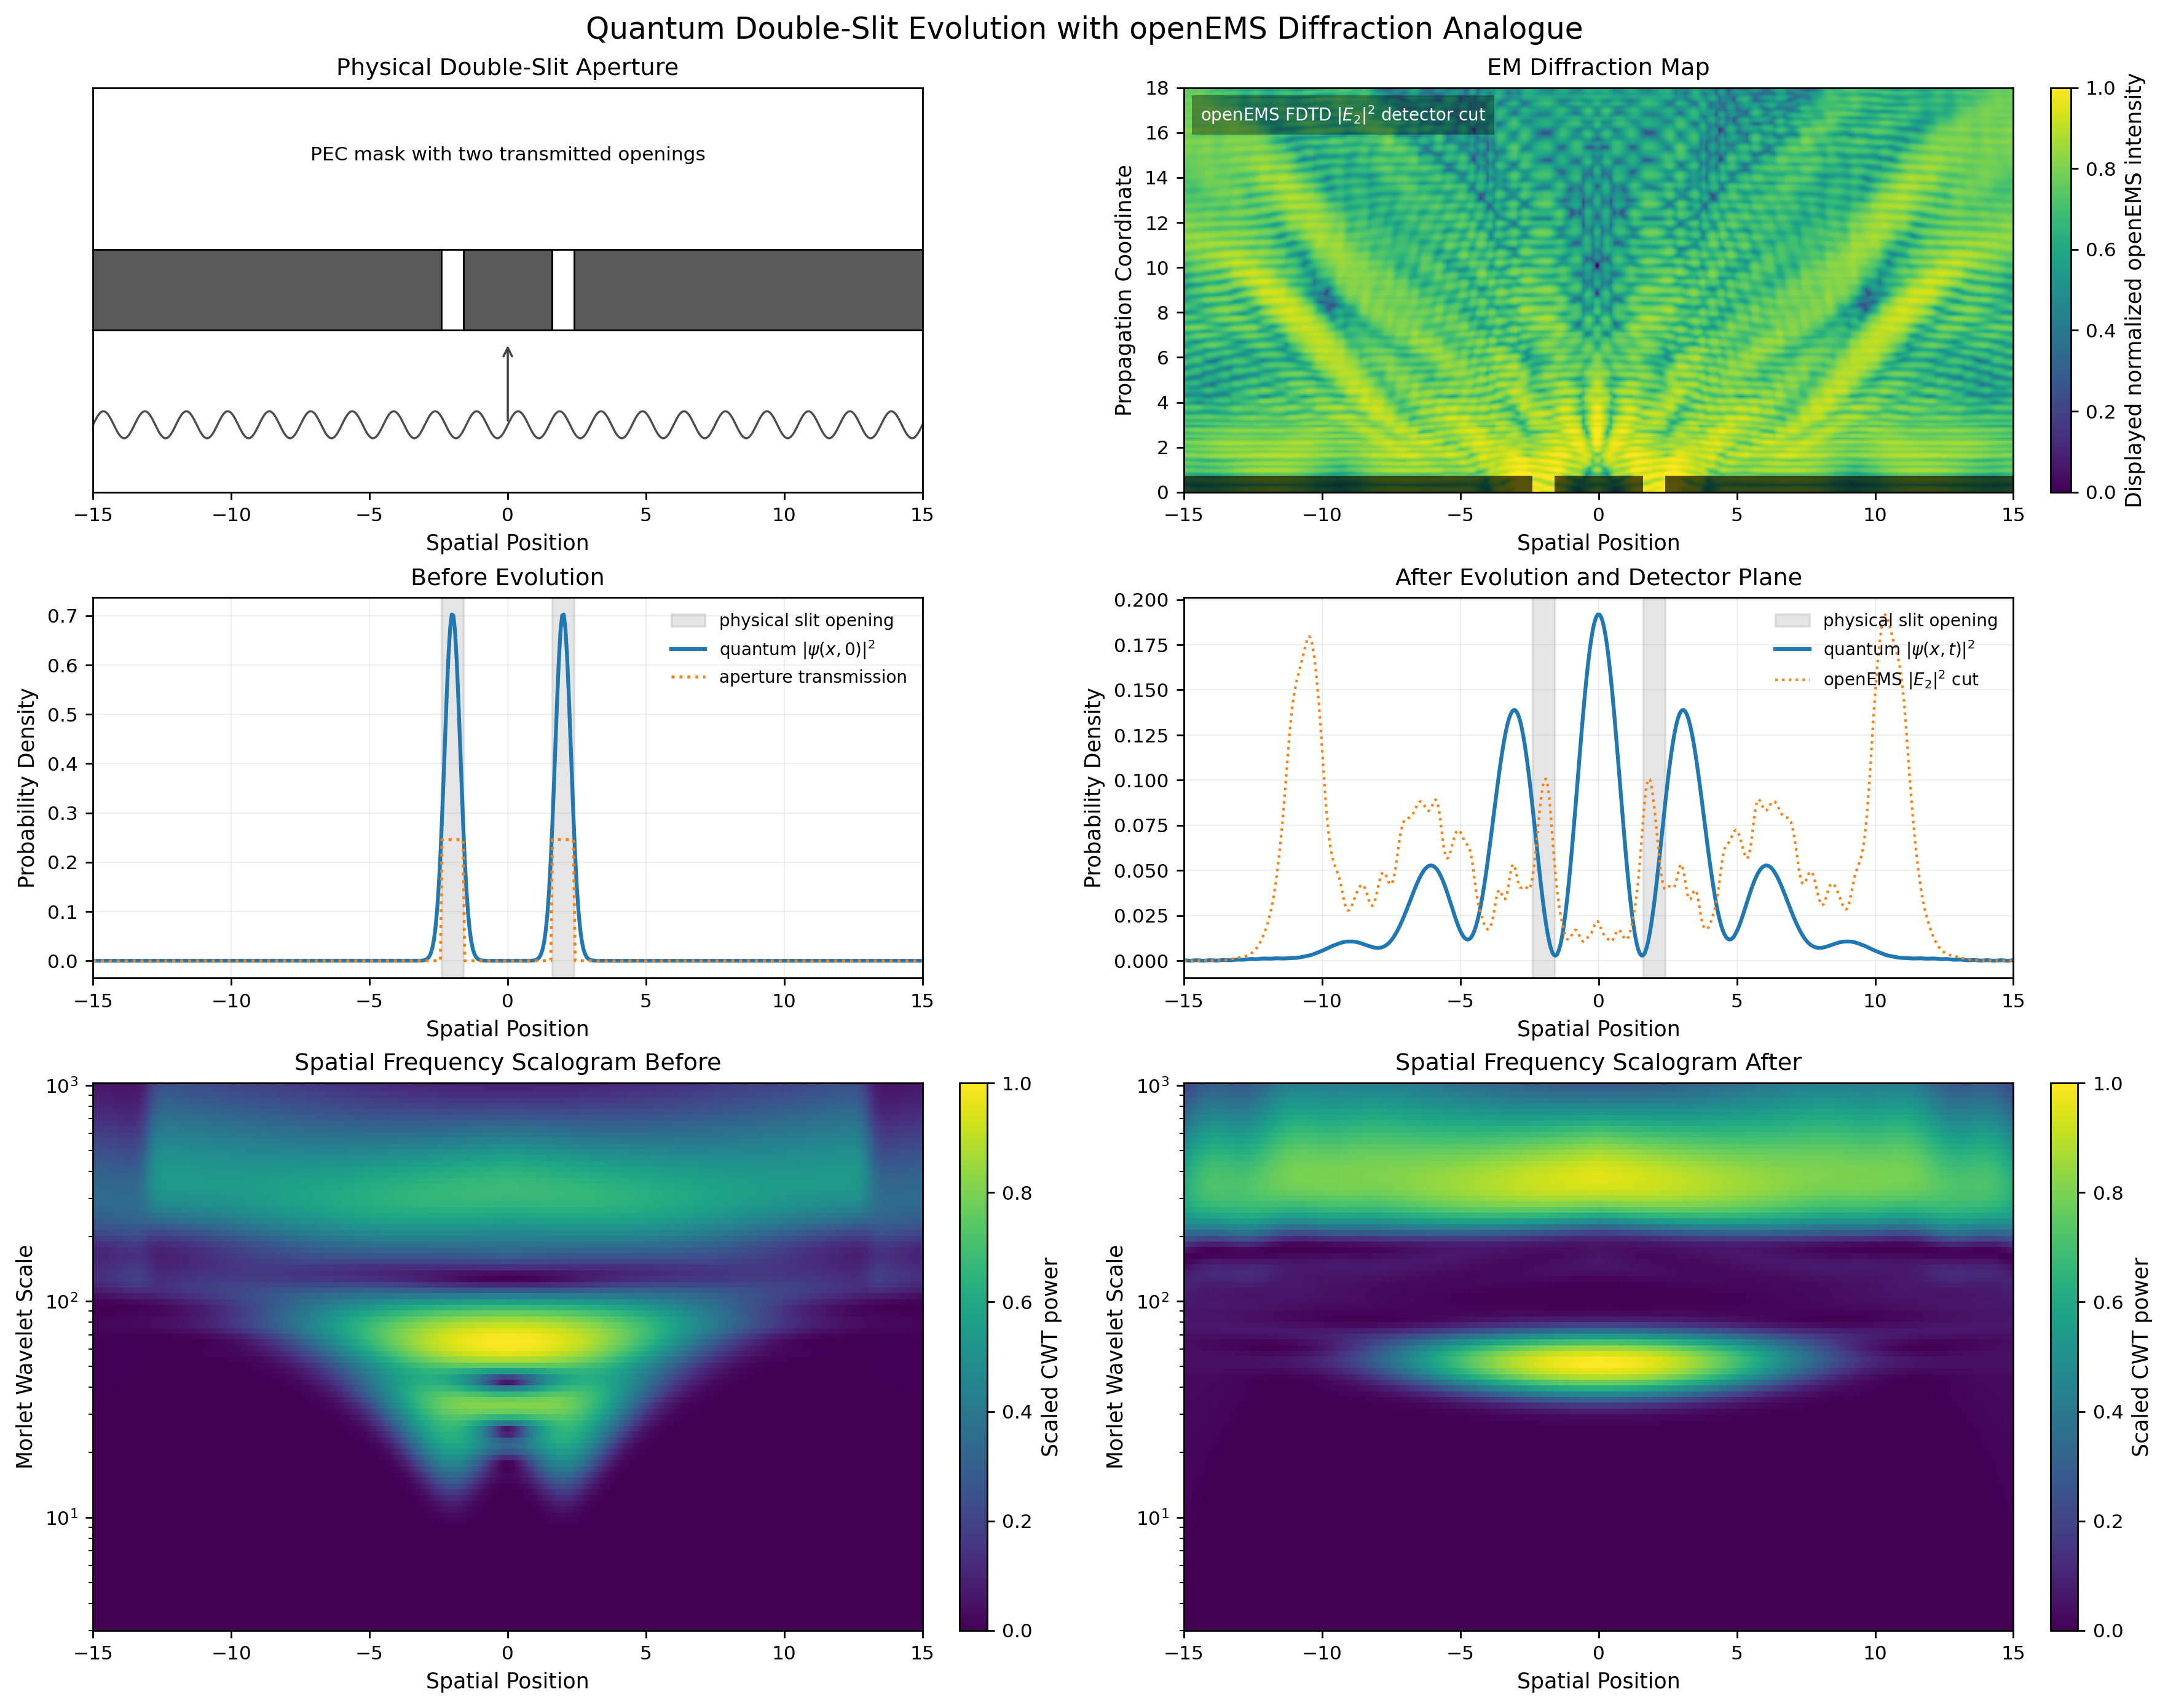

Selected openEMS HDF5: /content/openems_double_slit/fdtd_run/Ez_fd.h5
Selected openEMS component: 2


In [18]:
from dataclasses import replace

import numpy as np
import scipy.ndimage as ndi


# =============================================================================
# CONTROL KNOBS
# =============================================================================

EDGE_CROP_FRACTION = 0.10
DETECTOR_ROW_FRACTION = 0.72
DETECTOR_BAND_ROWS = 11
CENTER_WINDOW_FRACTION = 0.72
CENTER_WINDOW_POWER = 8.0
DETECTOR_SMOOTHING_SIGMA = 2.0
DISPLAY_SMOOTHING_SIGMA_Y = 0.70
DISPLAY_SMOOTHING_SIGMA_X = 0.35


def normalize_unit_interval(values: np.ndarray) -> np.ndarray:
    """Normalize an array into the unit interval."""

    array = np.asarray(values, dtype=np.float64)
    array = np.nan_to_num(array, nan=0.0, posinf=0.0, neginf=0.0)
    array = array - float(np.min(array))
    peak = float(np.max(array))

    if peak <= 0.0:
        return np.zeros_like(array)

    return array / peak


def normalize_positive_image(values: np.ndarray) -> np.ndarray:
    """Normalize a positive image without losing tiny openEMS fields."""

    array = np.asarray(values, dtype=np.float64)
    array = np.nan_to_num(array, nan=0.0, posinf=0.0, neginf=0.0)
    array = np.maximum(array, 0.0)
    peak = float(np.max(array))

    if peak <= 0.0:
        return np.zeros_like(array)

    return array / peak


def crop_lateral_edges(
    image: np.ndarray,
    crop_fraction: float,
) -> np.ndarray:
    """Crop side regions that are usually dominated by boundary response."""

    array = normalize_positive_image(image)
    column_count = array.shape[1]
    crop_count = int(round(crop_fraction * column_count))

    if crop_count <= 0:
        return array

    if 2 * crop_count >= column_count:
        return array

    return array[:, crop_count: column_count - crop_count]


def resize_image_to_target(
    image: np.ndarray,
    target_shape: tuple[int, int],
) -> np.ndarray:
    """Resize a two-dimensional field image to a target plotting shape."""

    source = normalize_positive_image(image)
    zoom_y = target_shape[0] / source.shape[0]
    zoom_x = target_shape[1] / source.shape[1]
    resized = ndi.zoom(source, (zoom_y, zoom_x), order=1)

    output = np.zeros(target_shape, dtype=np.float64)
    row_count = min(target_shape[0], resized.shape[0])
    column_count = min(target_shape[1], resized.shape[1])
    output[:row_count, :column_count] = resized[:row_count, :column_count]

    return normalize_positive_image(output)


def contrast_enhanced_display_map(
    image: np.ndarray,
    config,
) -> np.ndarray:
    """Create a visually stable display map from a normalized openEMS image."""

    array = normalize_positive_image(image)
    positive = array[array > 0.0]

    if positive.size == 0:
        return np.zeros_like(array)

    scale = float(np.percentile(positive, config.em_display_percentile))
    if scale <= 0.0:
        scale = float(np.max(positive))

    scaled = np.clip(array / scale, 0.0, 1.0)
    gain = 10.0 ** (config.em_dynamic_range_db / 10.0)
    scaled = np.log1p((gain - 1.0) * scaled) / np.log(gain)
    scaled = np.power(np.clip(scaled, 0.0, 1.0), config.em_display_gamma)
    scaled = ndi.gaussian_filter(
        scaled,
        sigma=(DISPLAY_SMOOTHING_SIGMA_Y, DISPLAY_SMOOTHING_SIGMA_X),
    )

    return normalize_unit_interval(scaled)


def central_detector_cut(
    normalized_map: np.ndarray,
    config,
) -> np.ndarray:
    """Extract a centered detector cut that suppresses edge artifacts."""

    row_count, column_count = normalized_map.shape
    detector_row = int(round(DETECTOR_ROW_FRACTION * (row_count - 1)))
    half_band = max(1, DETECTOR_BAND_ROWS // 2)

    row_start = max(0, detector_row - half_band)
    row_stop = min(row_count, detector_row + half_band + 1)
    detector_cut = np.mean(normalized_map[row_start:row_stop, :], axis=0)

    x_normalized = np.linspace(-1.0, 1.0, column_count)
    center_width = max(CENTER_WINDOW_FRACTION, 1e-6)
    center_window = np.exp(
        -((np.abs(x_normalized) / center_width) ** CENTER_WINDOW_POWER)
    )

    detector_cut = detector_cut * center_window
    detector_cut = ndi.gaussian_filter1d(
        detector_cut,
        sigma=DETECTOR_SMOOTHING_SIGMA,
    )

    return normalize_unit_interval(detector_cut)


def make_compatible_em_result(
    x_grid: np.ndarray,
    y_grid: np.ndarray,
    display_map: np.ndarray,
    normalized_map: np.ndarray,
    detector_cut: np.ndarray,
    component: int,
    hdf5_path,
):
    """Construct an EMResult across the recent result dataclass variants."""

    fields = getattr(EMResult, "__dataclass_fields__", {})

    kwargs = {
        "x_grid": x_grid,
        "y_grid": y_grid,
        "display_intensity_map": display_map,
        "detector_intensity": detector_cut,
    }

    if "normalized_intensity_map" in fields:
        kwargs["normalized_intensity_map"] = normalized_map

    if "raw_intensity_map" in fields:
        kwargs["raw_intensity_map"] = normalized_map

    if "selected_component" in fields:
        kwargs["selected_component"] = component

    if "selected_hdf5" in fields:
        kwargs["selected_hdf5"] = str(hdf5_path)

    if "source_label" in fields:
        kwargs["source_label"] = (
            rf"openEMS FDTD central $|E_{{{component}}}|^2$ cut"
        )

    if "used_openems" in fields:
        kwargs["used_openems"] = True

    if "intensity_map" in fields:
        kwargs["intensity_map"] = display_map

    return EMResult(**kwargs)


def compute_openems_result_refined(
    x_grid: np.ndarray,
    config,
):
    """Compute a cleaner openEMS result using central window postprocessing."""

    raw_image, component, hdf5_path, raw_peak = get_openems_field_image(config)

    cropped_image = crop_lateral_edges(raw_image, EDGE_CROP_FRACTION)
    normalized_map = resize_image_to_target(
        cropped_image,
        target_shape=(config.em_plot_y_points, config.grid_points),
    )
    display_map = contrast_enhanced_display_map(normalized_map, config)
    detector_cut = central_detector_cut(normalized_map, config)

    y_grid = np.linspace(
        config.openems_mask_y,
        config.openems_detector_y,
        config.em_plot_y_points,
    )

    print("Refined openEMS postprocessing")
    print(f"  Selected HDF5: {hdf5_path}")
    print(f"  Selected component: {component}")
    print(f"  Raw peak before normalization: {raw_peak:.6e}")
    print(f"  Cropped image shape: {cropped_image.shape}")
    print(f"  Normalized map peak: {float(np.max(normalized_map)):.6e}")
    print(f"  Detector cut peak: {float(np.max(detector_cut)):.6e}")

    return make_compatible_em_result(
        x_grid=x_grid,
        y_grid=y_grid,
        display_map=display_map,
        normalized_map=normalized_map,
        detector_cut=detector_cut,
        component=component,
        hdf5_path=hdf5_path,
    )


# Override the previous brute force postprocessor and reuse the existing HDF5.
compute_openems_result = compute_openems_result_refined
REFINED_CONFIG = replace(CONFIG, openems_force_rerun=False)

generate_figure(REFINED_CONFIG)